In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Change to project root
if Path.cwd().name == "lstm":
    os.chdir("../..")
elif Path.cwd().name == "notebooks":
    os.chdir("..")


REPO = Path.home() / "pv_forecast_30d"

# Measured base (has timestamp_utc, plant_id, power_norm, lstm_enc_*, plus some features)
BASE_DIR = REPO / "data/processed/pretraining/germany/global/tft_inputs"

# PVLib outputs you just built
PVLIB_DIR = REPO / "data/processed/pretraining/germany/global/pvlib_tft"

TRAIN_BASE = BASE_DIR / "regional_train_tft_base.parquet"
VAL_BASE   = BASE_DIR / "regional_val_tft_base.parquet"

TRAIN_PVLIB = PVLIB_DIR / "regional_train_pvlib_tft.parquet"
VAL_PVLIB   = PVLIB_DIR / "regional_val_pvlib_tft.parquet"

KEYS = ["plant_id", "timestamp_utc"]

print("TRAIN_BASE exists:", TRAIN_BASE.exists())
print("VAL_BASE exists:", VAL_BASE.exists())
print("TRAIN_PVLIB exists:", TRAIN_PVLIB.exists())
print("VAL_PVLIB exists:", VAL_PVLIB.exists())


TRAIN_BASE exists: True
VAL_BASE exists: True
TRAIN_PVLIB exists: True
VAL_PVLIB exists: True


In [2]:
tb = pd.read_parquet(TRAIN_BASE)
vb = pd.read_parquet(VAL_BASE)
tp = pd.read_parquet(TRAIN_PVLIB)
vp = pd.read_parquet(VAL_PVLIB)

for name, df in [("train_base", tb), ("val_base", vb), ("train_pvlib", tp), ("val_pvlib", vp)]:
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    print("\n==", name, "==")
    print("rows:", len(df), "cols:", df.shape[1])
    print("time:", df["timestamp_utc"].min(), "->", df["timestamp_utc"].max())
    print("plants:", sorted(df["plant_id"].unique().tolist()))
    print("has plant_04:", "plant_04" in set(df["plant_id"].unique()))

# Must be omitted everywhere
assert "plant_04" not in set(tb["plant_id"].unique())
assert "plant_04" not in set(vb["plant_id"].unique())
assert "plant_04" not in set(tp["plant_id"].unique())
assert "plant_04" not in set(vp["plant_id"].unique())

# Coverage must match base split
assert set(tb["plant_id"].unique()) == set(tp["plant_id"].unique())
assert set(vb["plant_id"].unique()) == set(vp["plant_id"].unique())



== train_base ==
rows: 142190 cols: 89
time: 2023-01-01 23:00:00+00:00 -> 2023-11-30 23:45:00+00:00
plants: ['plant_01', 'plant_02', 'plant_03', 'plant_05', 'plant_06']
has plant_04: False

== val_base ==
rows: 36952 cols: 89
time: 2023-12-02 00:00:00+00:00 -> 2024-02-29 23:45:00+00:00
plants: ['plant_01', 'plant_02', 'plant_03', 'plant_05', 'plant_06']
has plant_04: False

== train_pvlib ==
rows: 142190 cols: 10
time: 2023-01-01 23:00:00+00:00 -> 2023-11-30 23:45:00+00:00
plants: ['plant_01', 'plant_02', 'plant_03', 'plant_05', 'plant_06']
has plant_04: False

== val_pvlib ==
rows: 36952 cols: 10
time: 2023-12-02 00:00:00+00:00 -> 2024-02-29 23:45:00+00:00
plants: ['plant_01', 'plant_02', 'plant_03', 'plant_05', 'plant_06']
has plant_04: False


In [3]:
def key_audit(a: pd.DataFrame, b: pd.DataFrame, name: str):
    a_dups = int(a.duplicated(KEYS).sum())
    b_dups = int(b.duplicated(KEYS).sum())
    print(f"\n[{name}] dup keys: a={a_dups}, b={b_dups}")
    assert a_dups == 0 and b_dups == 0

    ma = a[KEYS].copy()
    mb = b[KEYS].copy()
    ma["__a"] = 1
    mb["__b"] = 1
    m = ma.merge(mb, on=KEYS, how="outer")
    both = int(((m["__a"] == 1) & (m["__b"] == 1)).sum())
    a_only = int(((m["__a"] == 1) & (m["__b"].isna())).sum())
    b_only = int(((m["__b"] == 1) & (m["__a"].isna())).sum())
    print(f"[{name}] both={both} a_only={a_only} b_only={b_only}")

    # For this pipeline, PVLib table should align 1:1 with base on the same split
    assert a_only == 0 and b_only == 0

key_audit(tb, tp, "TRAIN")
key_audit(vb, vp, "VAL")



[TRAIN] dup keys: a=0, b=0
[TRAIN] both=142190 a_only=0 b_only=0

[VAL] dup keys: a=0, b=0
[VAL] both=36952 a_only=0 b_only=0


In [4]:
def pick_pvlib_power_col(df: pd.DataFrame) -> str:
    # ignore keys
    cand = [c for c in df.columns if c not in KEYS]
    # prefer something that looks like a power output
    prefer = [c for c in cand if any(s in c.lower() for s in ["p_ac", "pac", "pdc", "power", "p_mp", "ac", "dc"])]
    if prefer:
        return prefer[0]
    # fallback: first numeric non-key
    num = [c for c in cand if pd.api.types.is_numeric_dtype(df[c])]
    if not num:
        raise ValueError("No numeric PVLib columns found.")
    return num[0]

pvcol_train = pick_pvlib_power_col(tp)
pvcol_val   = pick_pvlib_power_col(vp)
print("PVLib power-like col (train):", pvcol_train)
print("PVLib power-like col (val):", pvcol_val)

# Merge measured (power_norm) with pvlib column
mt = tb[KEYS + ["power_norm"]].merge(tp[KEYS + [pvcol_train]], on=KEYS, how="inner")
mv = vb[KEYS + ["power_norm"]].merge(vp[KEYS + [pvcol_val]],   on=KEYS, how="inner")

def per_plant_scores(m: pd.DataFrame, pvcol: str) -> pd.DataFrame:
    out = []
    for pid, g in m.groupby("plant_id"):
        y = g["power_norm"].astype(float).to_numpy()
        p = g[pvcol].astype(float).to_numpy()

        # Normalize pvlib to 0..1 per plant to make it comparable to power_norm.
        # This is a sanity check, not a physics-perfect calibration.
        pmin, pmax = np.nanmin(p), np.nanmax(p)
        p01 = (p - pmin) / (pmax - pmin) if (np.isfinite(pmin) and np.isfinite(pmax) and (pmax - pmin) > 0) else np.full_like(p, np.nan)

        mask = np.isfinite(y) & np.isfinite(p01)
        if mask.sum() == 0:
            out.append({"plant_id": pid, "n": 0, "corr": np.nan, "rmse": np.nan})
            continue

        yy = y[mask]
        pp = p01[mask]
        corr = float(np.corrcoef(yy, pp)[0, 1]) if len(yy) > 2 else np.nan
        rmse = float(np.sqrt(np.mean((yy - pp) ** 2)))
        out.append({"plant_id": pid, "n": int(mask.sum()), "corr": corr, "rmse": rmse})
    return pd.DataFrame(out).sort_values("plant_id")

print("\nTRAIN scores (pvlib normalized 0..1 per plant):")
display(per_plant_scores(mt, pvcol_train))

print("\nVAL scores (pvlib normalized 0..1 per plant):")
display(per_plant_scores(mv, pvcol_val))


PVLib power-like col (train): pvlib_dc_kw
PVLib power-like col (val): pvlib_dc_kw

TRAIN scores (pvlib normalized 0..1 per plant):


,plant_id,n,corr,rmse
0,plant_01,31875,0.873548,0.140908
1,plant_02,31875,0.873204,0.130131
2,plant_03,31972,0.792498,0.167719
3,plant_05,14496,0.441822,0.246098
4,plant_06,31972,0.798379,0.153844



VAL scores (pvlib normalized 0..1 per plant):


,plant_id,n,corr,rmse
0,plant_01,8543,0.809821,0.120970
1,plant_02,8540,0.832501,0.107781
2,plant_03,2781,0.289687,0.184804
3,plant_05,8448,0.622730,0.119131
4,plant_06,8640,0.745304,0.127476


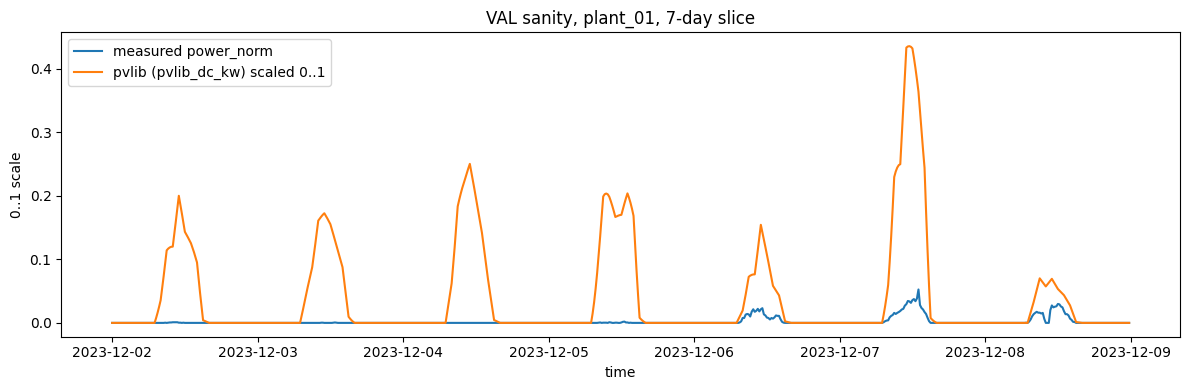

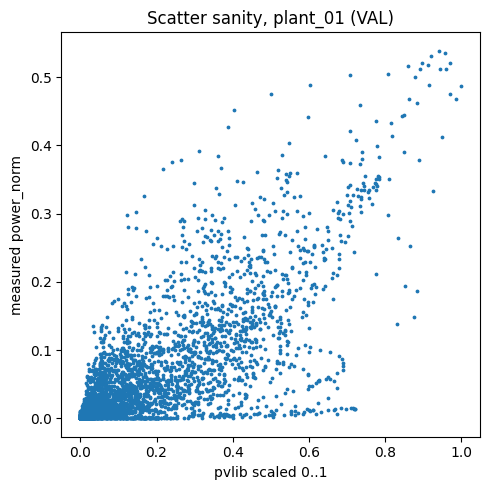

In [5]:
# Pick a plant and a short window from VAL (hardest split)
pid = sorted(mv["plant_id"].unique())[0]

g = mv[mv["plant_id"] == pid].sort_values("timestamp_utc").copy()

# Build pvlib 0..1 for plotting (same as above)
p = g[pvcol_val].astype(float).to_numpy()
pmin, pmax = np.nanmin(p), np.nanmax(p)
g["pvlib_01"] = (p - pmin) / (pmax - pmin) if (pmax - pmin) > 0 else np.nan

# Choose a 7-day slice starting at the first timestamp
t0 = g["timestamp_utc"].iloc[0]
t1 = t0 + pd.Timedelta(days=7)
w = g[(g["timestamp_utc"] >= t0) & (g["timestamp_utc"] < t1)].copy()

plt.figure(figsize=(12, 4))
plt.plot(w["timestamp_utc"], w["power_norm"].to_numpy(), label="measured power_norm")
plt.plot(w["timestamp_utc"], w["pvlib_01"].to_numpy(), label=f"pvlib ({pvcol_val}) scaled 0..1")
plt.title(f"VAL sanity, {pid}, 7-day slice")
plt.xlabel("time")
plt.ylabel("0..1 scale")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(g["pvlib_01"].to_numpy(), g["power_norm"].to_numpy(), s=3)
plt.title(f"Scatter sanity, {pid} (VAL)")
plt.xlabel("pvlib scaled 0..1")
plt.ylabel("measured power_norm")
plt.tight_layout()
plt.show()
